In [1]:
import pandas as pd
mde = pd.read_excel('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/output_files/KOLF_Pan_Genome_Filtered_Replogle_Pipeline_Modified_MDE_clusters.xlsx')
z_day_6 = pd.read_excel('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/input_files/D6-D14-Fitness-Z-Scores.xlsx', sheet_name='KOLF2-D6')[['id','Zscore']]
z_day_6.rename(columns={'id': 'gene_target', 'Zscore': 'Fitness_Z_Score_D6'}, inplace=True)
z_day_14 = pd.read_excel('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/input_files/D6-D14-Fitness-Z-Scores.xlsx', sheet_name='KOLF2-D14')[['id','Zscore']]
z_day_14.rename(columns={'id': 'gene_target', 'Zscore': 'Fitness_Z_Score_D14'}, inplace=True)
perturbation_stats = pd.read_csv('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/output_files/KOLF_Pan_Genome_Energy_Test_DEGs_Per_Gene_Target_Filtered.csv')[['gene_target','n_DEGs','edist']]
# Merge z_day_6
mde = mde.merge(z_day_6, on='gene_target', how='left')
# Merge z_day_14
mde = mde.merge(z_day_14, on='gene_target', how='left')
# Merge perturbation_stats
mde = mde.merge(perturbation_stats, on='gene_target', how='left')
mde.to_csv('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/output_files/KOLF_Pan_Genome_strong_perturbation_stats.csv', index=False)

In [2]:
mde

,x,y,gene_target,leiden cluster,hdbscan cluster,Fitness_Z_Score_D6,Fitness_Z_Score_D14,n_DEGs,edist
0,-5.395267,-7.587446,AARS2,29,26,0.285725,-0.461480,38.0,12.264185
1,-6.525729,-0.205314,ABCF1,41,-1,-0.195094,-0.575224,147.0,16.611575
2,-0.490103,-0.589435,ABHD8,42,-1,0.385903,0.576947,3.0,5.469292
3,0.297504,2.954107,ABHD17A,26,-1,0.539768,0.538428,9.0,4.831043
4,-6.760030,2.321144,ABI2,25,-1,-0.241699,-1.138716,30.0,5.591879
...,...,...,...,...,...,...,...,...,...
1651,10.501936,5.405953,ZNF695,55,17,0.528638,0.468538,23.0,4.645483
1652,6.179829,-3.235291,ZNF787,12,-1,1.010729,1.767045,6.0,18.600422
1653,6.705886,-1.812036,ZNF888,7,-1,0.309801,0.696586,2.0,18.108005
1654,0.885618,5.022110,ZNRF1,0,-1,0.022917,-0.089016,2.0,16.367373


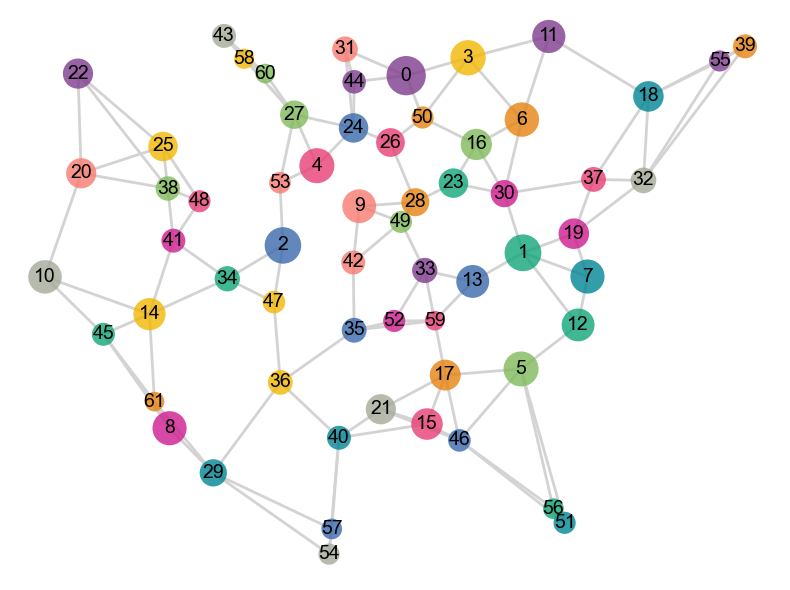

In [4]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
import plotly.express as px
plt.rcParams['font.family'] = 'Arial'


# --- 1. Compute per-cluster centroids and sizes ---
clusters = (
    mde
    .groupby('leiden cluster')
    .agg(
        x_centroid=('x', 'mean'),
        y_centroid=('y', 'mean'),
        size=('x', 'size')
    )
    .reset_index()
)

# --- 2. 3 nearest neighbors per centroid ---
coords = clusters[['x_centroid', 'y_centroid']].values
nbrs = NearestNeighbors(n_neighbors=4).fit(coords)
_, indices = nbrs.kneighbors(coords)
edges = {
    tuple(sorted((i, j)))
    for i, neighs in enumerate(indices)
    for j in neighs[1:]
}

# --- 3. Grab Plotly Bold palette and convert it for Matplotlib ---
raw_palette = px.colors.qualitative.Bold
mpl_palette = []
for c in raw_palette:
    if c.startswith('rgb'):
        r, g, b = map(int, re.findall(r'\d+', c))
        mpl_palette.append((r/255, g/255, b/255))
    else:
        mpl_palette.append(c)

color_map = {
    cl: mpl_palette[idx % len(mpl_palette)]
    for idx, cl in enumerate(clusters['leiden cluster'])
}

# --- 4. Sizes into a tighter range ---
min_s, max_s = 200, 800
sz = clusters['size']
sz_norm = (sz - sz.min()) / (sz.max() - sz.min())
marker_sizes = min_s + sz_norm * (max_s - min_s)

# --- 5. Plot everything ---
fig, ax = plt.subplots(figsize=(8, 6))

# 5a) draw thicker 2-NN edges
for i, j in edges:
    x0, y0 = coords[i]
    x1, y1 = coords[j]
    ax.plot([x0, x1], [y0, y1], color='lightgray', lw=2, zorder=1)

# 5b) draw each centroid without border
for idx, row in clusters.iterrows():
    x, y = row['x_centroid'], row['y_centroid']
    cl = int(row['leiden cluster'])
    ax.scatter(
        x, y,
        s=marker_sizes[idx],
        facecolor=color_map[cl],
        edgecolor='none',   # no border
        alpha=0.8,
        zorder=2
    )
    ax.text(
        x, y,
        str(cl),
        ha='center', va='center',
        fontsize=14,
        zorder=3
    )

# 6. Turn off axes entirely
ax.axis('off')

plt.tight_layout()
fig.savefig('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/output_files/sleton_mde.svg')
plt.show()


In [96]:
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
import plotly.express as px

def plot_cluster_map(
    df,
    cluster_col: str = 'leiden cluster',
    x_col: str = 'x',
    y_col: str = 'y',
    value_col: str = None,
    cmap: str = 'viridis',
    k_neighbors: int = 3,
    min_s: float = 200,
    max_s: float = 800,
    line_width: float = 2.0,
    alpha: float = 0.8,
    figsize=(8, 6),
    cbar_lims: tuple = None  # (vmin, vmax) for colorbar limits
):
    """
    Draw cluster‐centroid graph:
      • centroids at mean(x),mean(y) per cluster
      • circle area ~ cluster size
      • edges to each centroid's k_neighbors nearest centroids
      • if value_col is None: qualitative Bold palette by cluster
        otherwise: color by median(value_col) with colormap `cmap` + colorbar
      • cbar_lims: optional (vmin, vmax) to set colorbar scale limits
    """
    # 1) compute centroid coords & cluster sizes & (optional) median value
    agg_dict = {
        'x_centroid': (x_col, 'mean'),
        'y_centroid': (y_col, 'mean'),
        'size':      (x_col, 'size')
    }
    if value_col:
        agg_dict['median_value'] = (value_col, 'median')

    clusters = (
        df
        .groupby(cluster_col)
        .agg(**agg_dict)
        .reset_index()
    )

    # 2) nearest neighbors
    coords = clusters[['x_centroid', 'y_centroid']].to_numpy()
    nbrs = NearestNeighbors(n_neighbors=k_neighbors+1).fit(coords)
    _, indices = nbrs.kneighbors(coords)
    edges = {
        tuple(sorted((i, j)))
        for i, neighs in enumerate(indices)
        for j in neighs[1:]
    }

    # 3) marker sizes
    sz = clusters['size']
    if sz.max() != sz.min():
        sz_norm = (sz - sz.min()) / (sz.max() - sz.min())
    else:
        sz_norm = np.zeros_like(sz)
    marker_sizes = min_s + sz_norm * (max_s - min_s)

    # 4) colors
    if value_col is None:
        raw_palette = px.colors.qualitative.Bold
        mpl_palette = []
        for c in raw_palette:
            if c.startswith('rgb'):
                r, g, b = map(int, re.findall(r'\d+', c))
                mpl_palette.append((r/255, g/255, b/255))
            else:
                mpl_palette.append(c)
        colors = [mpl_palette[i % len(mpl_palette)] for i in range(len(clusters))]
        norm = None
    else:
        # determine vmin/vmax
        vals = clusters['median_value'].to_numpy()
        if cbar_lims:
            vmin, vmax = cbar_lims
        else:
            vmin, vmax = np.nanmin(vals), np.nanmax(vals)
        cmap_obj = plt.get_cmap(cmap)
        normed = (vals - vmin) / (vmax - vmin) if vmax != vmin else np.zeros_like(vals)
        colors = cmap_obj(normed)

    # 5) plotting
    fig, ax = plt.subplots(figsize=figsize)
    # edges
    for i, j in edges:
        x0, y0 = coords[i]
        x1, y1 = coords[j]
        ax.plot([x0, x1], [y0, y1], color='lightgray', lw=line_width, zorder=1)
    # centroids
    for idx, row in clusters.iterrows():
        ax.scatter(
            row['x_centroid'], row['y_centroid'],
            s=marker_sizes[idx], facecolor=colors[idx],
            edgecolor='none', alpha=alpha, zorder=2
        )
        ax.text(
            row['x_centroid'], row['y_centroid'],
            str(int(row[cluster_col])), ha='center', va='center',
            fontsize=14, zorder=3
        )

    # colorbar
    if value_col:
        sm = plt.cm.ScalarMappable(cmap=cmap_obj,
                                   norm=plt.Normalize(vmin=vmin, vmax=vmax))
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.02)
        cbar.set_label(f"Median {value_col}")

    ax.axis('off')
    plt.tight_layout()
    return fig




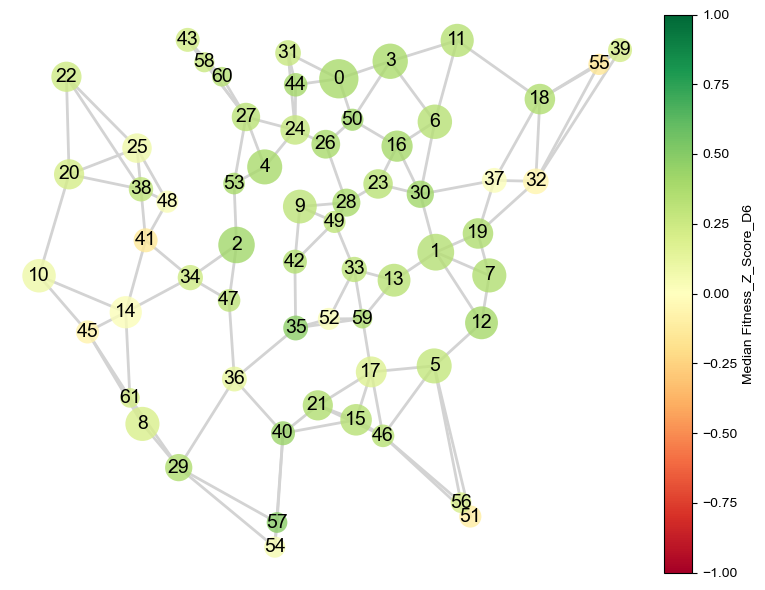

In [103]:
# --- Example usage ---
# color by median n_DEGs with the “plasma” cmap:
fig = plot_cluster_map(
    mde,
    cluster_col='leiden cluster',
    x_col='x', y_col='y',
    value_col='Fitness_Z_Score_D6',
    cmap='RdYlGn',
    cbar_lims = (-1,1),
    k_neighbors=3
)
fig.savefig('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/output_files/skeleton_mde_D6.svg')

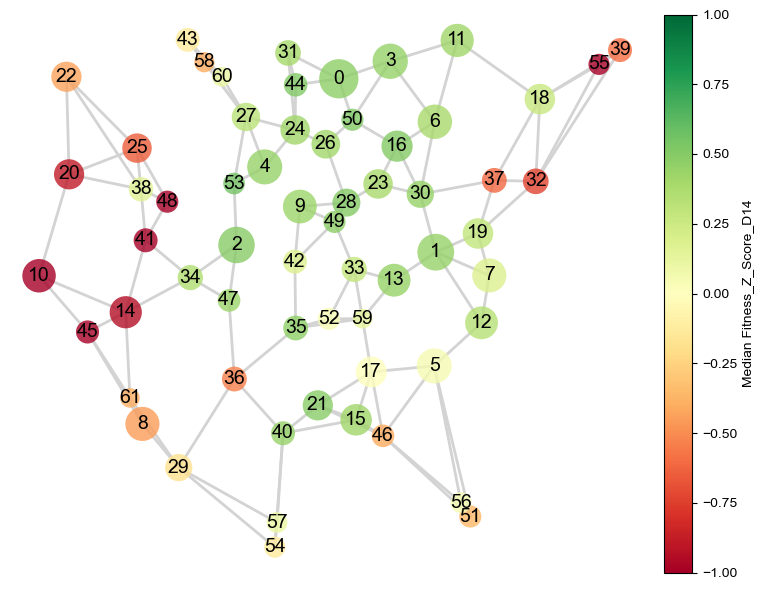

In [104]:
fig = plot_cluster_map(
    mde,
    cluster_col='leiden cluster',
    x_col='x', y_col='y',
    value_col='Fitness_Z_Score_D14',
    cmap='RdYlGn',
    cbar_lims = (-1,1),
    k_neighbors=3
)
fig.savefig('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/output_files/skeleton_mde_D14.svg')

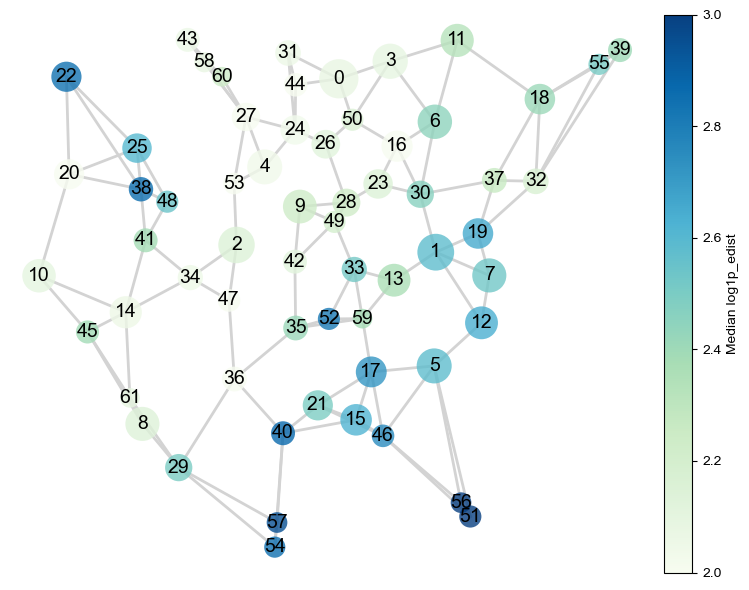

In [109]:
mde['log1p_edist'] = np.log1p(mde['edist'])
fig = plot_cluster_map(
    mde,
    cluster_col='leiden cluster',
    x_col='x', y_col='y',
    value_col='log1p_edist',
    cmap='GnBu',
    k_neighbors=3,
    cbar_lims = (2,3)
)
fig.savefig('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/output_files/skeleton_mde_edist.svg')

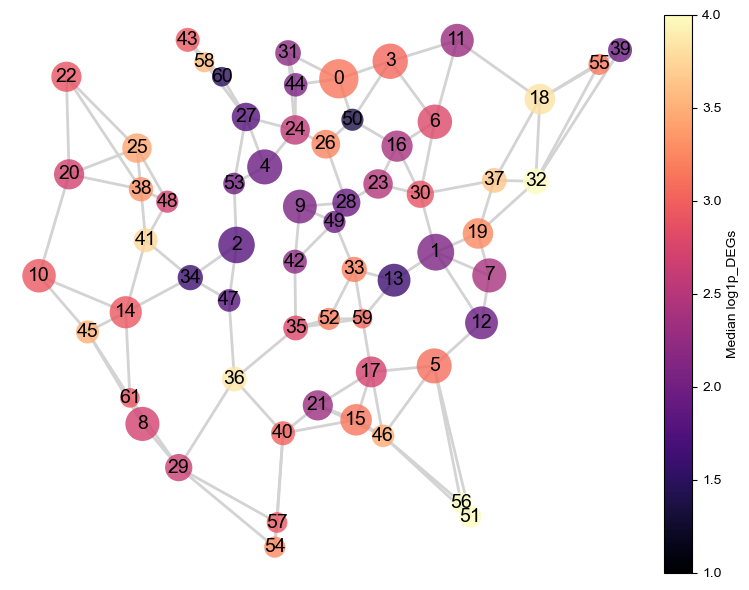

In [106]:
mde['log1p_DEGs'] = np.log1p(mde['n_DEGs'])
fig = plot_cluster_map(
    mde,
    cluster_col='leiden cluster',
    x_col='x', y_col='y',
    value_col='log1p_DEGs',
    cmap='magma',
    k_neighbors=3,
    cbar_lims = (1,4)
)
fig.savefig('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/output_files/skeleton_mde_DEGs.svg')